In [1]:
import shap
import joblib
import os
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

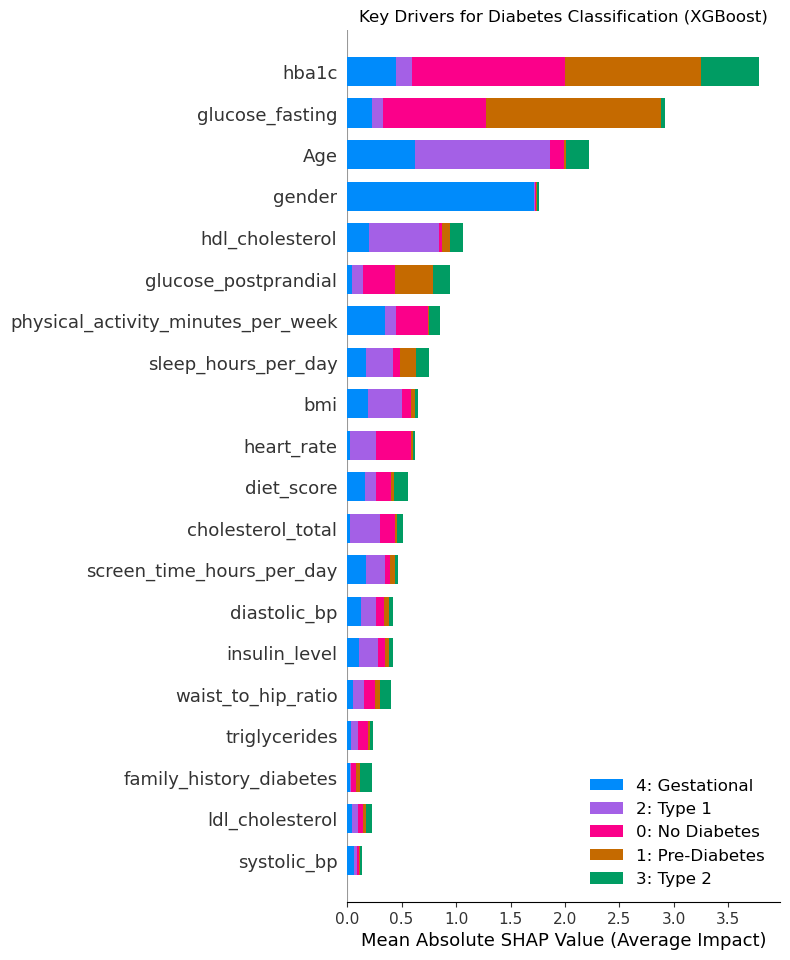

In [2]:
# 1. Load your artifacts (Adjust paths if necessary)
xgb_model = joblib.load('../artifacts/xgboost_model.pkl')
X_test_scaled = pd.read_csv('../data/processed/X_test_scaled.csv') 

# 2. Calculate the SHAP values (This defines the missing variable)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

# 3. Define Labels with Numbers
target_names = [
    '0: No Diabetes', 
    '1: Pre-Diabetes', 
    '2: Type 1', 
    '3: Type 2', 
    '4: Gestational'
]

# 4. Generate the readable Bar Plot
shap.summary_plot(
    shap_values, 
    X_test_scaled, 
    class_names=target_names, 
    plot_type="bar", 
    show=False
)

plt.title("Key Drivers for Diabetes Classification (XGBoost)")
plt.xlabel("Mean Absolute SHAP Value (Average Impact)")
plt.show()

In [3]:
# 1. Align features
model_features = surrogate.feature_names_in_
X_sample_aligned = X_sample[model_features]

# 2. Loop through and display all 3 clusters
for cluster_idx in range(3):
    # Slice the 3D array: [rows, features, cluster]
    sv_slice = shap_values_km[:, :, cluster_idx]
    
    # Initialize the plot
    plt.figure(figsize=(10, 6))
    
    # Generate the beeswarm
    shap.summary_plot(
        sv_slice, 
        X_sample_aligned, 
        show=False
    )
    
    # Formatting
    plt.title(f"Key Drivers: Patient Segment cluster {cluster_idx}")
    plt.tight_layout()
    
    # This forces the notebook to render the plot before moving to the next iteration
    plt.show()

NameError: name 'surrogate' is not defined

# Patient Segment Profiles

## Cluster 0: Baseline / Low-Risk Segment
- Statistical Core: This represents the healthiest segment of the sample with an average age of 44.

- Clinical Profile: Characterized by the lowest metabolic markers, maintaining a mean HbA1c of 5.8 and Fasting Glucose of 100 mg/dL.

- SHAP Driver Insight: Analysis shows that low glucose and low HbA1c are the primary inclusive drivers (appearing as blue on the right of the beeswarm).

- Practical Context: This group serves as the "Control" segment, representing younger individuals with stable metabolic health.

## Cluster 1: High-Risk Metabolic Segment
- Statistical Core: Comprises approximately 20,479 patients (~30% of the sample).

- Clinical Profile: Exhibits the highest clinical risk in the dataset, with a mean HbA1c of 7.09 and Fasting Glucose of 118 mg/dL.

- SHAP Driver Insight: HbA1c is the dominant predictor for this group. Despite having a lower average BMI (24.1) than Cluster 2, the model groups them based on aggressive internal blood chemistry.

- Practical Context: These patients represent "High-Risk" cases where glycemic dysfunction is the primary concern, independent of obesity.

## Cluster 2: Senior / Lifestyle-Driven Segment
- Statistical Core: Includes approximately 22,898 patients (~34% of the sample).

- Clinical Profile: The oldest segment (avg. age 57) with the highest average BMI (28.3) and elevated glucose (115 mg/dL).

- SHAP Driver Insight: This group is defined by the intersection of Age and BMI. Unlike Cluster 1, these patients are grouped based on the physiological markers of aging and increased body mass.

- Practical Context: This group represents "Age-Related Risk," where lifestyle interventions like weight management and physical activity are likely the highest-impact treatments.